In [1]:
# ============================================================
# CELL 1: Cài đặt và import thư viện
# ============================================================
!pip install imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Import thư viện thành công!")

✅ Import thư viện thành công!


In [2]:
# ============================================================
# CELL 2: Kết nối Google Drive và đọc dữ liệu
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os
import glob

# Đường dẫn tới folder chứa dataset
DATA_PATH = '/content/drive/MyDrive/IDS_Dataset/'

# Tìm tất cả file CSV
csv_files = glob.glob(DATA_PATH + '*.csv')
print(f"📁 Tìm thấy {len(csv_files)} file CSV:")
for f in csv_files:
    print(f"   - {os.path.basename(f)}")

Mounted at /content/drive
📁 Tìm thấy 8 file CSV:
   - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
   - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
   - Friday-WorkingHours-Morning.pcap_ISCX.csv
   - Monday-WorkingHours.pcap_ISCX.csv
   - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
   - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
   - Tuesday-WorkingHours.pcap_ISCX.csv
   - Wednesday-workingHours.pcap_ISCX.csv


In [3]:
# ============================================================
# CELL 3: Gộp tất cả CSV thành 1 DataFrame lớn
# ============================================================
print("⏳ Đang đọc dữ liệu, vui lòng chờ...")

dfs = []
for file in csv_files:
    df_temp = pd.read_csv(file, encoding='utf-8', low_memory=False)
    dfs.append(df_temp)
    print(f"   ✅ {os.path.basename(file)} — {df_temp.shape[0]:,} dòng")

# Gộp lại
df = pd.concat(dfs, ignore_index=True)
print(f"\n🎉 Tổng cộng: {df.shape[0]:,} dòng | {df.shape[1]} cột")
print(f"📊 Bộ nhớ sử dụng: {df.memory_usage().sum() / 1024**2:.1f} MB")

⏳ Đang đọc dữ liệu, vui lòng chờ...
   ✅ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv — 225,745 dòng
   ✅ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv — 286,467 dòng
   ✅ Friday-WorkingHours-Morning.pcap_ISCX.csv — 191,033 dòng
   ✅ Monday-WorkingHours.pcap_ISCX.csv — 529,918 dòng
   ✅ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv — 288,602 dòng
   ✅ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv — 170,366 dòng
   ✅ Tuesday-WorkingHours.pcap_ISCX.csv — 445,909 dòng
   ✅ Wednesday-workingHours.pcap_ISCX.csv — 692,703 dòng

🎉 Tổng cộng: 2,830,743 dòng | 79 cột
📊 Bộ nhớ sử dụng: 1706.2 MB


In [4]:
# ============================================================
# CELL 4: Làm sạch dữ liệu (Data Cleaning)
# ============================================================

print("🧹 Bắt đầu làm sạch dữ liệu...")
print(f"   Shape ban đầu: {df.shape}")

# 1. Xóa khoảng trắng thừa ở tên cột
df.columns = df.columns.str.strip()
print("   ✅ Đã xóa khoảng trắng tên cột")

# 2. Thay thế giá trị vô cực (inf) và NaN bằng median
df.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df.select_dtypes(include=[np.number]).columns:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
print("   ✅ Đã xử lý giá trị NaN và Inf")

# 3. Xóa các cột có variance = 0 (không mang thông tin gì)
before = df.shape[1]
numeric_cols = df.select_dtypes(include=[np.number]).columns
zero_var_cols = [col for col in numeric_cols if df[col].var() == 0]
df.drop(columns=zero_var_cols, inplace=True)
print(f"   ✅ Đã xóa {len(zero_var_cols)} cột zero-variance: {zero_var_cols}")

# 4. Xóa dòng trùng lặp
before_rows = df.shape[0]
df.drop_duplicates(inplace=True)
after_rows = df.shape[0]
print(f"   ✅ Đã xóa {before_rows - after_rows:,} dòng trùng lặp")

print(f"\n📊 Shape sau khi làm sạch: {df.shape}")

🧹 Bắt đầu làm sạch dữ liệu...
   Shape ban đầu: (2830743, 79)
   ✅ Đã xóa khoảng trắng tên cột
   ✅ Đã xử lý giá trị NaN và Inf
   ✅ Đã xóa 8 cột zero-variance: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
   ✅ Đã xóa 308,381 dòng trùng lặp

📊 Shape sau khi làm sạch: (2522362, 71)


In [5]:
# ============================================================
# CELL 5: Tối ưu bộ nhớ bằng cách downcast kiểu dữ liệu
# ============================================================

print(f"💾 Bộ nhớ trước khi tối ưu: {df.memory_usage().sum() / 1024**2:.1f} MB")

# Downcast số nguyên
for col in df.select_dtypes(include=['int64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='unsigned')

# Downcast số thực
for col in df.select_dtypes(include=['float64']).columns:
    df[col] = pd.to_numeric(df[col], downcast='float')

print(f"💾 Bộ nhớ sau khi tối ưu:  {df.memory_usage().sum() / 1024**2:.1f} MB")
print("✅ Tối ưu bộ nhớ thành công!")

💾 Bộ nhớ trước khi tối ưu: 1385.6 MB
💾 Bộ nhớ sau khi tối ưu:  839.5 MB
✅ Tối ưu bộ nhớ thành công!


📊 Phân bố nhãn (Label):
Label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


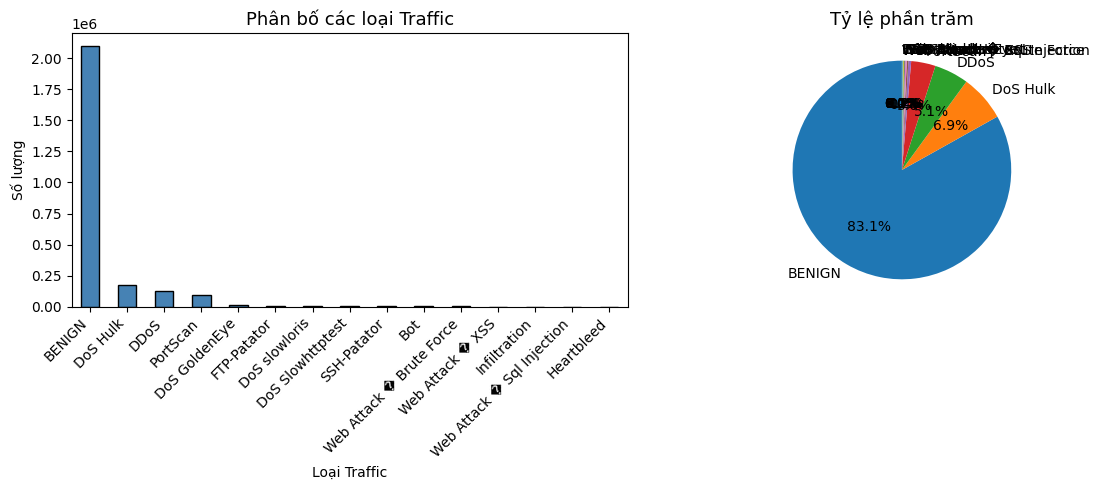

✅ Đã lưu biểu đồ: attack_distribution.png


In [6]:
# ============================================================
# CELL 6: EDA - Xem phân bố các loại traffic
# ============================================================

print("📊 Phân bố nhãn (Label):")
label_counts = df['Label'].value_counts()
print(label_counts)

# Vẽ biểu đồ
plt.figure(figsize=(12, 5))

# Biểu đồ bar
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Phân bố các loại Traffic', fontsize=13)
plt.xlabel('Loại Traffic')
plt.ylabel('Số lượng')
plt.xticks(rotation=45, ha='right')

# Biểu đồ pie (bỏ nhãn nhỏ cho gọn)
plt.subplot(1, 2, 2)
label_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Tỷ lệ phần trăm', fontsize=13)
plt.ylabel('')

plt.tight_layout()
plt.savefig('attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu biểu đồ: attack_distribution.png")

✅ Số features đã chọn: 18
📋 Danh sách features:
    1. Destination Port
    2. Flow Duration
    3. Total Fwd Packets
    4. Total Backward Packets
    5. Total Length of Fwd Packets
    6. Total Length of Bwd Packets
    7. Fwd Packet Length Mean
    8. Bwd Packet Length Mean
    9. Flow Bytes/s
   10. Flow Packets/s
   11. Packet Length Mean
   12. Packet Length Std
   13. SYN Flag Count
   14. ACK Flag Count
   15. FIN Flag Count
   16. RST Flag Count
   17. PSH Flag Count
   18. URG Flag Count

⏳ Đang vẽ Correlation Heatmap...


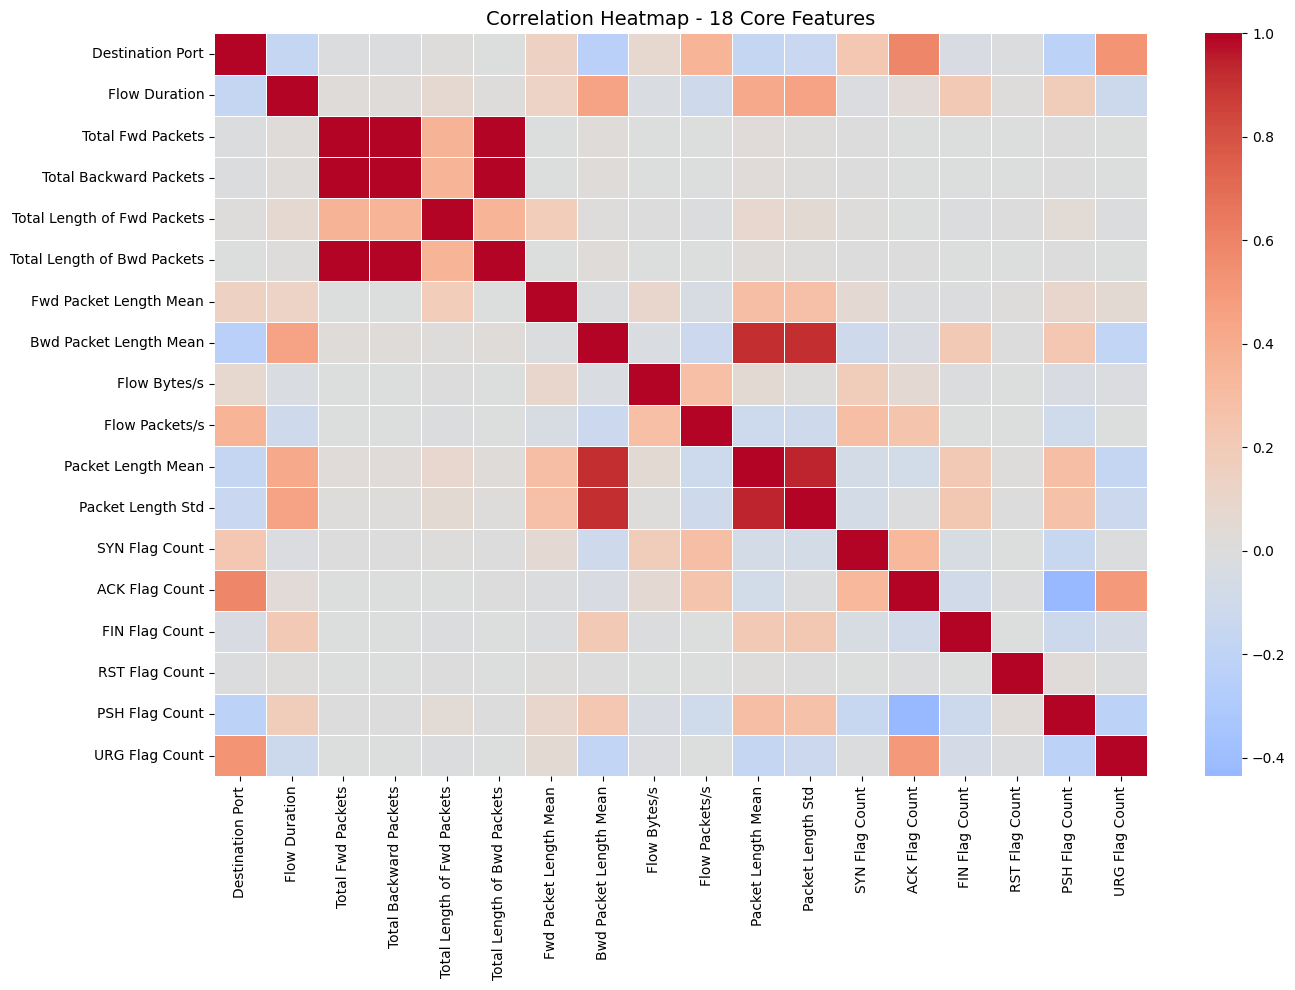

✅ Đã lưu biểu đồ: correlation_heatmap.png


In [10]:
# ============================================================
# CELL 7 (FIX): Cập nhật lại tên features đúng với dataset
# ============================================================

selected_features = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count',
    'ACK Flag Count', 'FIN Flag Count', 'RST Flag Count',
    'PSH Flag Count', 'URG Flag Count'
]

print(f"✅ Số features đã chọn: {len(selected_features)}")
print("📋 Danh sách features:")
for i, f in enumerate(selected_features, 1):
    print(f"   {i:2d}. {f}")

# Vẽ Correlation Heatmap
print("\n⏳ Đang vẽ Correlation Heatmap...")
plt.figure(figsize=(14, 10))
corr_matrix = df[selected_features].corr()
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Correlation Heatmap - 18 Core Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu biểu đồ: correlation_heatmap.png")

In [11]:
# ============================================================
# CELL 8: Encode Label + Scale features
# ============================================================
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# 1. Tách features và label
X = df[selected_features]
y = df['Label']

# 2. Encode nhãn (chuyển text → số)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("📋 Mapping nhãn:")
for i, label in enumerate(le.classes_):
    print(f"   {i:2d} → {label}")

# 3. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=selected_features)

print(f"\n✅ Encode và Scale xong!")
print(f"   Shape X: {X_scaled.shape}")
print(f"   Shape y: {y_encoded.shape}")

📋 Mapping nhãn:
    0 → BENIGN
    1 → Bot
    2 → DDoS
    3 → DoS GoldenEye
    4 → DoS Hulk
    5 → DoS Slowhttptest
    6 → DoS slowloris
    7 → FTP-Patator
    8 → Heartbleed
    9 → Infiltration
   10 → PortScan
   11 → SSH-Patator
   12 → Web Attack � Brute Force
   13 → Web Attack � Sql Injection
   14 → Web Attack � XSS

✅ Encode và Scale xong!
   Shape X: (2522362, 18)
   Shape y: (2522362,)


In [12]:
# ============================================================
# CELL 9: Chia tập Train / Test
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Giữ tỷ lệ các class
)

print(f"✅ Chia dữ liệu xong!")
print(f"   Train: {X_train.shape[0]:,} dòng")
print(f"   Test:  {X_test.shape[0]:,} dòng")

✅ Chia dữ liệu xong!
   Train: 2,017,889 dòng
   Test:  504,473 dòng


In [13]:
# ============================================================
# CELL 10: Cân bằng dữ liệu (SMOTE + RandomUnderSampler)
# ============================================================
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from collections import Counter

print("⏳ Đang cân bằng dữ liệu (có thể mất 3-5 phút)...")
print(f"   Phân bố trước: {dict(list(Counter(y_train).items())[:5])} ...")

# Đếm số lượng class lớn nhất
max_count = Counter(y_train).most_common(1)[0][1]

# SMOTE: Tăng minority class lên 10% của majority class
smote_strategy = {
    cls: max(count, int(max_count * 0.1))
    for cls, count in Counter(y_train).items()
    if count < int(max_count * 0.1)
}

# Pipeline: SMOTE → RandomUnderSampler
pipeline = Pipeline([
    ('smote', SMOTE(sampling_strategy=smote_strategy, random_state=42, k_neighbors=3)),
    ('under', RandomUnderSampler(sampling_strategy={
        list(Counter(y_train).most_common(1))[0][0]: int(max_count * 0.5)
    }, random_state=42))
])

X_train_bal, y_train_bal = pipeline.fit_resample(X_train, y_train)

print(f"\n✅ Cân bằng xong!")
print(f"   Train trước: {len(y_train):,} dòng")
print(f"   Train sau:   {len(y_train_bal):,} dòng")
print(f"   Phân bố sau: {Counter(y_train_bal)}")

⏳ Đang cân bằng dữ liệu (có thể mất 3-5 phút)...
   Phân bố trước: {np.int64(4): 138279, np.int64(0): 1677187, np.int64(10): 72655, np.int64(2): 102413, np.int64(12): 1176} ...

✅ Cân bằng xong!
   Train trước: 2,017,889 dòng
   Train sau:   3,186,645 dòng
   Phân bố sau: Counter({np.int64(0): 838593, np.int64(1): 167718, np.int64(2): 167718, np.int64(3): 167718, np.int64(4): 167718, np.int64(5): 167718, np.int64(6): 167718, np.int64(7): 167718, np.int64(8): 167718, np.int64(9): 167718, np.int64(10): 167718, np.int64(11): 167718, np.int64(12): 167718, np.int64(13): 167718, np.int64(14): 167718})
